In [1]:
#Assignment 1

In [2]:
import pandas as pd
import numpy as np

In [3]:
employees = pd.DataFrame({
    'emp_id': [1,2,3,4],
    'name': ['Alice','Bob','Charlie','Diana'],
    'dept_id': [101,102,101,103]
})

departments = pd.DataFrame({
    'dept_id': [101,102,103,104],
    'dept_name': ['HR','Finance','IT','Marketing']
})

salaries = pd.DataFrame({
    'emp_id': [1,2,3,4],
    'salary': [70000,80000,75000,90000]
})

print(employees)
print(departments)
print(salaries)

   emp_id     name  dept_id
0       1    Alice      101
1       2      Bob      102
2       3  Charlie      101
3       4    Diana      103
   dept_id  dept_name
0      101         HR
1      102    Finance
2      103         IT
3      104  Marketing
   emp_id  salary
0       1   70000
1       2   80000
2       3   75000
3       4   90000


In [4]:
inner_merge = pd.merge(employees, departments, on='dept_id', how='inner')
print("Inner Join:\n", inner_merge)

Inner Join:
    emp_id     name  dept_id dept_name
0       1    Alice      101        HR
1       2      Bob      102   Finance
2       3  Charlie      101        HR
3       4    Diana      103        IT


In [5]:
left_merge = pd.merge(employees, departments, on='dept_id', how='left')
print("Left Join:\n", left_merge)

Left Join:
    emp_id     name  dept_id dept_name
0       1    Alice      101        HR
1       2      Bob      102   Finance
2       3  Charlie      101        HR
3       4    Diana      103        IT


In [6]:
new_employees = pd.DataFrame({
    'emp_id': [5,6],
    'name': ['Eve','Frank'],
    'dept_id': [102,104]
})

all_employees = pd.concat([employees, new_employees], ignore_index=True)
print(all_employees)

   emp_id     name  dept_id
0       1    Alice      101
1       2      Bob      102
2       3  Charlie      101
3       4    Diana      103
4       5      Eve      102
5       6    Frank      104


In [7]:
emp_salary = pd.merge(all_employees, salaries, on='emp_id', how='left')
print(emp_salary)

   emp_id     name  dept_id   salary
0       1    Alice      101  70000.0
1       2      Bob      102  80000.0
2       3  Charlie      101  75000.0
3       4    Diana      103  90000.0
4       5      Eve      102      NaN
5       6    Frank      104      NaN


In [8]:
avg_salary = emp_salary.groupby('dept_id')['salary'].mean().reset_index()
print(avg_salary)

   dept_id   salary
0      101  72500.0
1      102  80000.0
2      103  90000.0
3      104      NaN


In [9]:
bins = [0, 60000, 80000, 100000]
labels = ['Low','Medium','High']

emp_salary['salary_category'] = pd.cut(emp_salary['salary'], bins=bins, labels=labels)
print(emp_salary)

   emp_id     name  dept_id   salary salary_category
0       1    Alice      101  70000.0          Medium
1       2      Bob      102  80000.0          Medium
2       3  Charlie      101  75000.0          Medium
3       4    Diana      103  90000.0            High
4       5      Eve      102      NaN             NaN
5       6    Frank      104      NaN             NaN


In [10]:
emp_salary.to_csv('employee_summary.csv', index=False)
print("CSV file saved as employee_summary.csv")

CSV file saved as employee_summary.csv


In [11]:
# Assignment 2

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
data = {
    'month': ['Jan','Feb','Mar','Apr','May','Jun'],
    'product_a': [120,150,170,160,180,200],
    'product_b': [100,130,160,150,170,190],
    'product_c': [90,110,140,130,150,180],
    'region': ['North','South','East','West','North','South']
}

df = pd.DataFrame(data)
print(df)

  month  product_a  product_b  product_c region
0   Jan        120        100         90  North
1   Feb        150        130        110  South
2   Mar        170        160        140   East
3   Apr        160        150        130   West
4   May        180        170        150  North
5   Jun        200        190        180  South


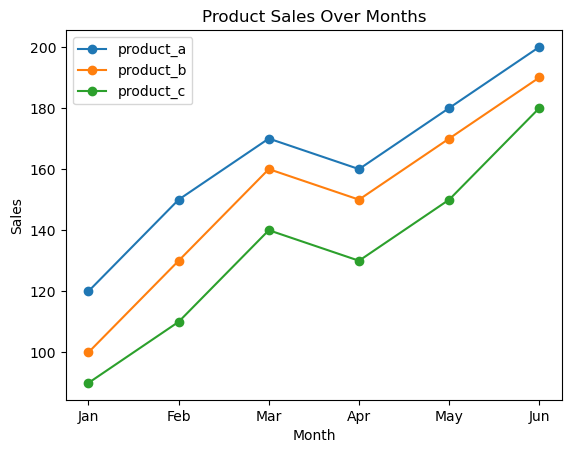

In [14]:
df.plot(x='month', y=['product_a','product_b','product_c'], marker='o')
plt.title("Product Sales Over Months")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

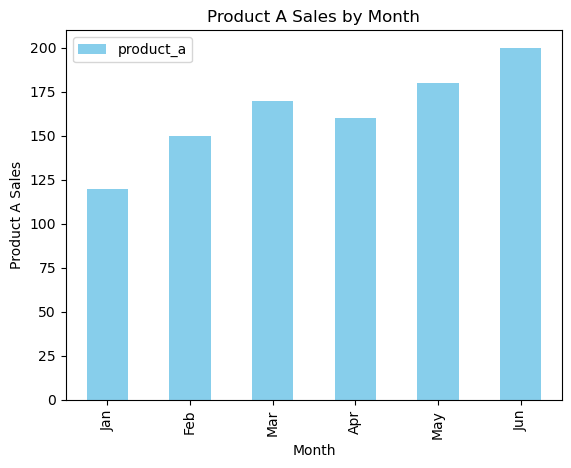

In [15]:
df.plot(kind='bar', x='month', y='product_a', color='skyblue')
plt.title("Product A Sales by Month")
plt.xlabel("Month")
plt.ylabel("Product A Sales")
plt.show()

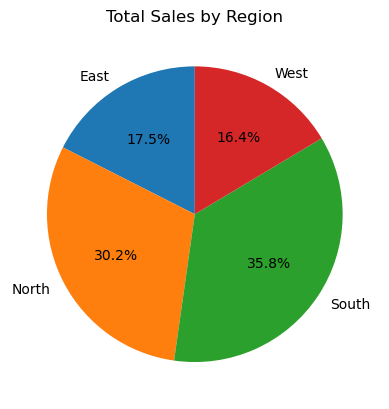

In [16]:
region_sales = df.groupby('region')[['product_a','product_b','product_c']].sum().sum(axis=1)
region_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Total Sales by Region")
plt.ylabel("")  # remove y-label
plt.show()

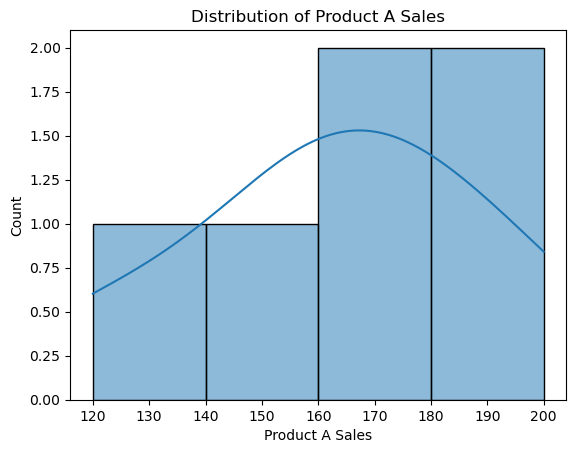

In [17]:
sns.histplot(df['product_a'], kde=True)
plt.title("Distribution of Product A Sales")
plt.xlabel("Product A Sales")
plt.show()

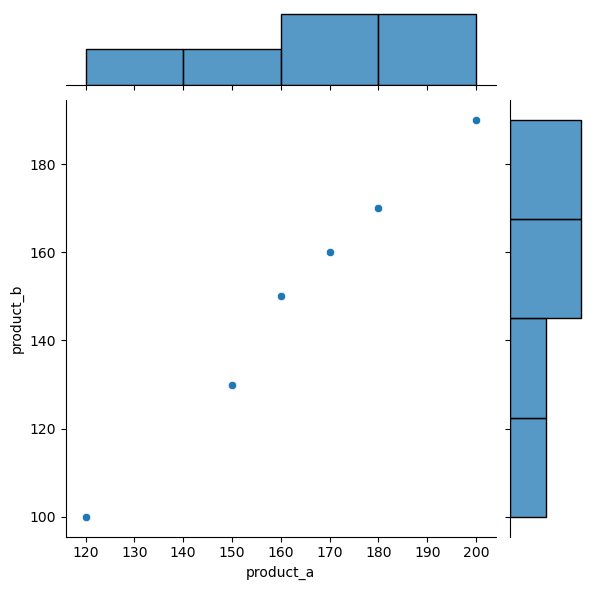

In [18]:
sns.jointplot(x='product_a', y='product_b', data=df, kind='scatter')
plt.show()

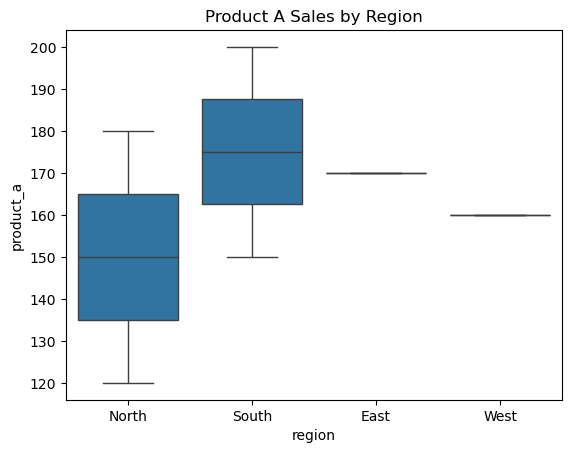

In [19]:
sns.boxplot(x='region', y='product_a', data=df)
plt.title("Product A Sales by Region")
plt.show()

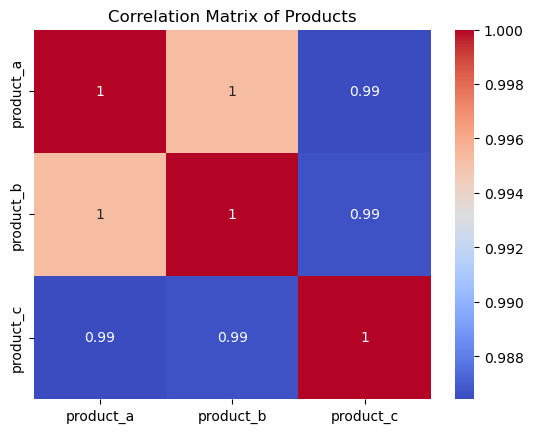

In [20]:
corr_matrix = df[['product_a','product_b','product_c']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Products")
plt.show()


In [21]:
# Assignment

In [22]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

y = np.array([15, 20, 25, 30, 35, 40, 45, 50, 55, 60])

In [25]:
m = 0   
b = 0    
learning_rate = 0.01
epochs = 1000
n = len(X)

In [ ]:
for i in range(epochs):
    y_pred = m*X + b
    
    cost = (1/n) * sum((y - y_pred)**2)
    
    m_gradient = (-2/n) * sum(X * (y - y_pred))
    b_gradient = (-2/n) * sum(y - y_pred)
    
    m = m - learning_rate * m_gradient
    b = b - learning_rate * b_gradient
    
    # Print cost every 100 epochs
    if i % 100 == 0:
        print(f"Epoch {i}, Cost: {cost:.4f}")